# EXHALE: effect of trace-metal cooling (C, N, O)

This notebook compares two **EXHALE** runs of the same planet
(HD 209458b), one with trace-metal cooling enabled and one without, to
show how the metals change the atmospheric structure. The metals (C, N, O)
are solved **inside the coupled MINPACK ionization system** (Badnell RR+DR
recombination, Voronov collisional ionization, Kingdon&Ferland charge
transfer with H), so their densities are written as extra columns of
`Ion_species.txt` (there is no separate `Metals_ioniz` file).

Generate the two result sets first:
```bash
./run_compare_metals.sh        # builds once; metals.inp present -> on, absent -> off
```
which writes `HD209458b/output_metals_on/` and `HD209458b/output_metals_off/`.

Column layout (EXHALE):
* `Hydro_ioniz.txt` : r, rho, v, p, T, heating, cooling
* `Ion_species.txt` : r, nHI, nHII, nHeI, nHeII, nHeIII, nHeITR,
  nCI, nCII, nCIII, nOI, nOII, nOIII, **nNI, nNII, nNIII** (16 columns)

Temperature, velocity, ionization and heating/cooling are read from the
time-loop solution (`Hydro_ioniz.txt`, `Ion_species.txt`), the clean
metal-on vs metal-off comparison.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

DIR_ON  = 'output_metals_on'
DIR_OFF = 'output_metals_off'

def load_hydro(d):
    r, rho, v, p, T, heat, cool = np.loadtxt(f'{d}/Hydro_ioniz.txt', unpack=True)
    return dict(r=r, rho=rho, v=v, p=p, T=T, heat=heat, cool=cool)

def load_ion(d):
    # H/He: first 7 columns of Ion_species.txt (also has metals in 8-16)
    r, nhi, nhii, nhei, nheii, nheiii, nheitr = np.loadtxt(
        f'{d}/Ion_species.txt', usecols=range(7), unpack=True)
    return dict(r=r, nHI=nhi, nHII=nhii, nHeI=nhei, nHeII=nheii,
                nHeIII=nheiii, nHeITR=nheitr)

def load_metals(d):
    # EXHALE: metals are columns 8-16 of Ion_species.txt (1-indexed):
    #   8-10 CI/CII/CIII, 11-13 OI/OII/OIII, 14-16 NI/NII/NIII
    a = np.loadtxt(f'{d}/Ion_species.txt', unpack=True)
    if a.shape[0] < 16:
        return None                      # H/He-only output
    names = ['CI','CII','CIII','OI','OII','OIII','NI','NII','NIII']
    out = {'r': a[0]}
    for i, nm in enumerate(names):
        out[nm] = a[7+i]
    if not any(np.any(out[nm] > 0) for nm in names):
        return None                      # metals-off run
    return out

H_on,  H_off  = load_hydro(DIR_ON),  load_hydro(DIR_OFF)
I_on,  I_off  = load_ion(DIR_ON),    load_ion(DIR_OFF)
M_on          = load_metals(DIR_ON)
print('metal species:', [k for k in M_on if k != 'r'] if M_on else None)
print('grid points:', H_on['r'].size)

metal species: ['CI', 'CII', 'CIII', 'OI', 'OII', 'OIII', 'NI', 'NII', 'NIII']
grid points: 504


## 1. Temperature profile
Metal-line cooling lowers the temperature; the difference
$\Delta T = T_{\rm off}-T_{\rm on}$ is largest in the partially-ionized layer.

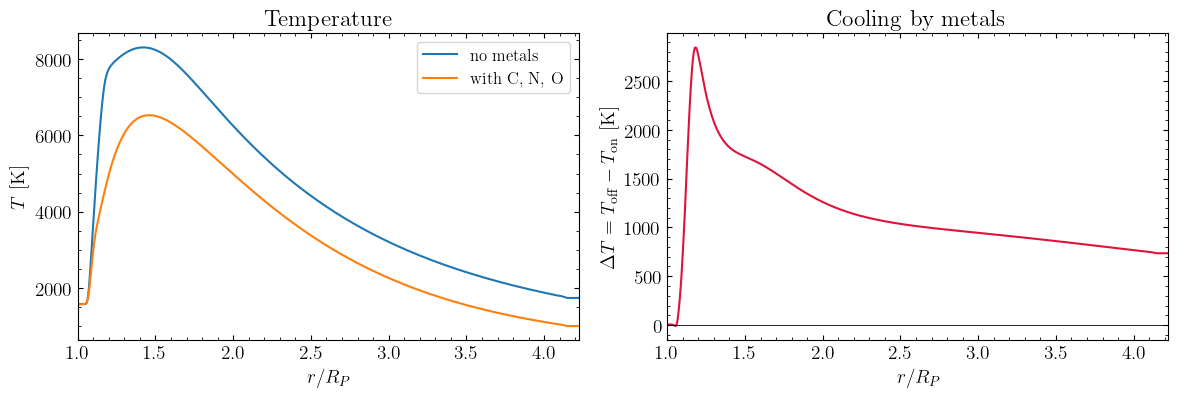

max dT = 2844.2 K at r/R_P = 1.181


In [2]:
r = H_on['r']
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ax[0].plot(r, H_off['T'], label='no metals')
ax[0].plot(r, H_on['T'],  label='with C, N, O')
ax[0].set_xlabel(r'$r/R_P$'); ax[0].set_ylabel(r'$T$ [K]')
ax[0].set_title('Temperature'); ax[0].legend(); ax[0].set_xlim(r[0], r[-1])

ax[1].plot(r, H_off['T'] - H_on['T'], color='crimson')
ax[1].axhline(0, color='k', lw=0.6)
ax[1].set_xlabel(r'$r/R_P$'); ax[1].set_ylabel(r'$\Delta T = T_{\rm off}-T_{\rm on}$ [K]')
ax[1].set_title('Cooling by metals'); ax[1].set_xlim(r[0], r[-1])
plt.tight_layout(); plt.show()

imax = np.argmax(H_off['T'] - H_on['T'])
print(f'max dT = {(H_off["T"]-H_on["T"])[imax]:.1f} K at r/R_P = {r[imax]:.3f}')

## 2. Velocity and mass-flux proxy
A cooler atmosphere is more bound, which can reduce the outflow. We plot
the velocity and the spherical mass-flux proxy $\rho\,v\,r^2$ (proportional
to $\dot M$).

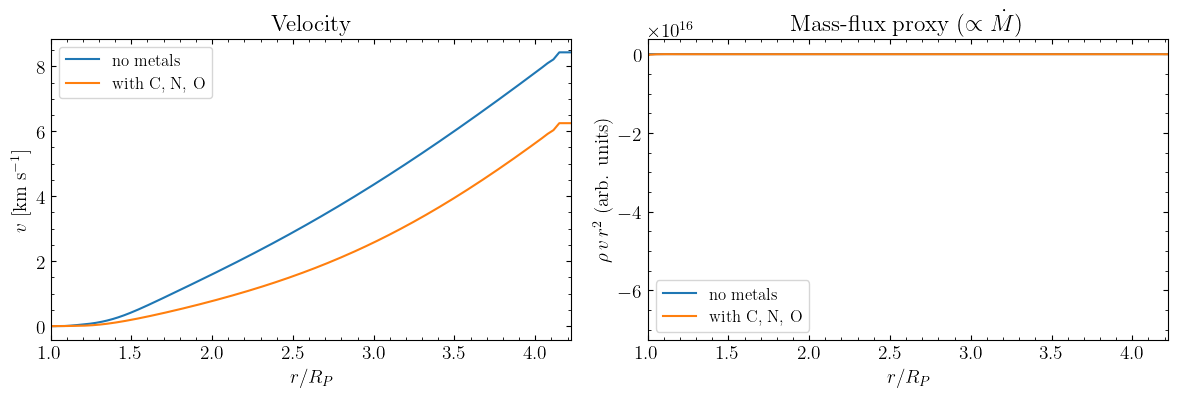

mean rho*v*r^2 ratio (on/off), outer region: 0.115


In [3]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ax[0].plot(r, H_off['v']/1e5, label='no metals')
ax[0].plot(r, H_on['v']/1e5,  label='with C, N, O')
ax[0].set_xlabel(r'$r/R_P$'); ax[0].set_ylabel(r'$v$ [km s$^{-1}$]')
ax[0].set_title('Velocity'); ax[0].legend(); ax[0].set_xlim(r[0], r[-1])

mf_off = H_off['rho'] * H_off['v'] * r**2
mf_on  = H_on['rho']  * H_on['v']  * r**2
ax[1].plot(r, mf_off, label='no metals')
ax[1].plot(r, mf_on,  label='with C, N, O')
ax[1].set_xlabel(r'$r/R_P$'); ax[1].set_ylabel(r'$\rho\,v\,r^2$ (arb. units)')
ax[1].set_title(r'Mass-flux proxy ($\propto \dot M$)'); ax[1].legend(); ax[1].set_xlim(r[0], r[-1])
plt.tight_layout(); plt.show()

# Mass-flux ratio in the (roughly constant) outer region
sel = r > 0.5*r[-1]
print(f'mean rho*v*r^2 ratio (on/off), outer region: {np.mean(mf_on[sel]/mf_off[sel]):.3f}')

## 3. Hydrogen / helium ionization
Cooling shifts the ionization balance. Compare the H ionization fraction
with and without metals.

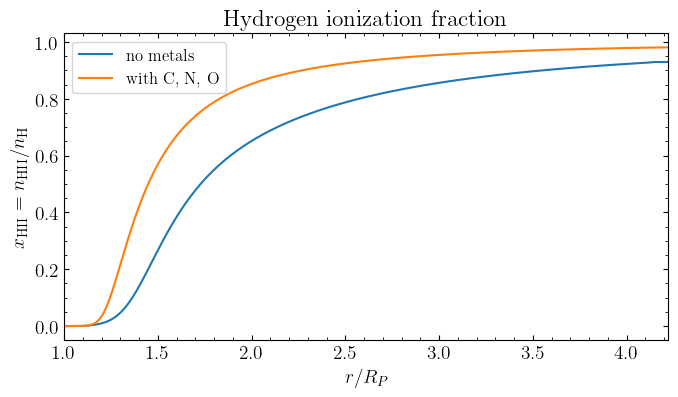

In [4]:
xHII_on  = I_on['nHII']  / (I_on['nHI']  + I_on['nHII'])
xHII_off = I_off['nHII'] / (I_off['nHI'] + I_off['nHII'])
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(r, xHII_off, label='no metals')
ax.plot(r, xHII_on,  label='with C, N, O')
ax.set_xlabel(r'$r/R_P$'); ax.set_ylabel(r'$x_{\rm HII} = n_{\rm HII}/n_{\rm H}$')
ax.set_title('Hydrogen ionization fraction'); ax.legend(); ax.set_xlim(r[0], r[-1])
plt.tight_layout(); plt.show()

## 4. Metal ionization structure (with-metals run)
Number densities and per-element ionization fractions of the tracked
metal stages.

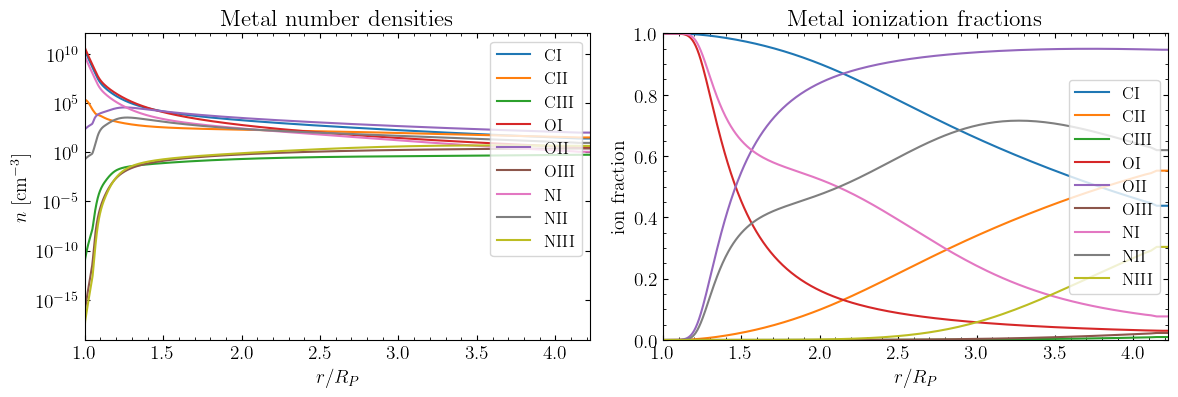

In [5]:
rm = M_on['r']
species = [k for k in M_on if k != 'r']
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
for nm in species:
    ax[0].semilogy(rm, M_on[nm], label=nm)
ax[0].set_xlabel(r'$r/R_P$'); ax[0].set_ylabel(r'$n$ [cm$^{-3}$]')
ax[0].set_title('Metal number densities'); ax[0].legend(); ax[0].set_xlim(rm[0], rm[-1])

# ionization fractions per element (stages come in consecutive triples)
for i in range(0, len(species), 3):
    grp = species[i:i+3]
    tot = sum(M_on[g] for g in grp)
    for g in grp:
        ax[1].plot(rm, M_on[g]/tot, label=g)
ax[1].set_xlabel(r'$r/R_P$'); ax[1].set_ylabel('ion fraction')
ax[1].set_title('Metal ionization fractions'); ax[1].legend(); ax[1].set_xlim(rm[0], rm[-1]); ax[1].set_ylim(0, 1)
plt.tight_layout(); plt.show()

## 5. Heating and cooling rates
The extra metal-line cooling appears as a larger total cooling rate in the
with-metals run.

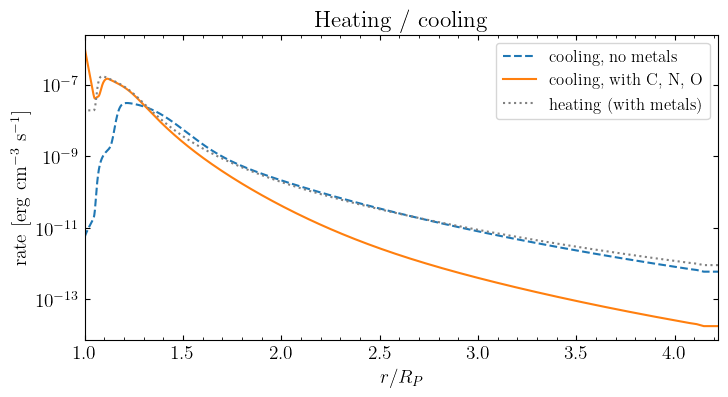

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.semilogy(r, H_off['cool'], '--', label='cooling, no metals')
ax.semilogy(r, H_on['cool'],       label='cooling, with C, N, O')
ax.semilogy(r, H_on['heat'], ':',  color='gray', label='heating (with metals)')
ax.set_xlabel(r'$r/R_P$'); ax.set_ylabel('rate [erg cm$^{-3}$ s$^{-1}$]')
ax.set_title('Heating / cooling'); ax.legend(); ax.set_xlim(r[0], r[-1])
plt.tight_layout(); plt.show()

## Summary
* Metal-line cooling (C, N, O) lowers the temperature, most strongly in
  the partially-ionized layer (cell 1).
* The cooler, more tightly bound atmosphere modifies the outflow velocity
  and mass-flux (cell 2) and the H ionization (cell 3).
* The metal ionization structure (cell 4) shows neutral metals near the
  base and progressive ionization outward; with charge transfer active,
  O (and partly N) ionization tracks hydrogen.

These metals are solved self-consistently in the MINPACK system (with
Badnell RR+DR and charge exchange), unlike the decoupled coronal solver
in `ATES_extended`. To compare a different planet, edit `input.inp` and
`metals.inp`, re-run `run_compare_metals.sh`, and re-execute this
notebook.